Make Your Own Least Squares- Homework 5

In [33]:
#imports required
import numpy as np
import matplotlib.pyplot as plt
import random
from scipy.interpolate import CubicSpline

Slope: 0.41898723950296834, Intercept: 1.4467257525284476


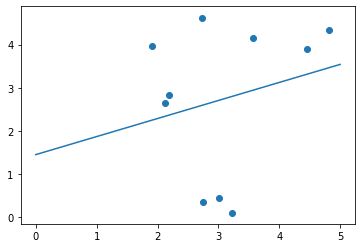

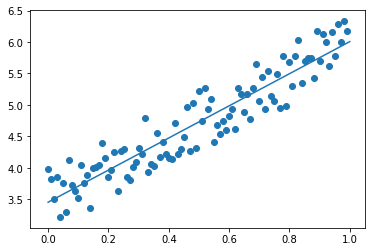

residuals=array([0.52435993, 0.34412318, 0.005667  , 0.32393983, 0.3390919 ,
       0.18177772, 0.31556699, 0.48497166, 0.06137408, 0.04658928,
       0.19747259, 0.31142851, 0.00743182, 0.10407481, 0.44634631,
       0.1517224 , 0.14540565, 0.14946695, 0.47550405, 0.21279929,
       0.11029009, 0.03354301, 0.22627925, 0.41190345, 0.19386081,
       0.19695499, 0.2640773 , 0.34631054, 0.16058547, 0.11308003,
       0.09262899, 0.03974324, 0.5092521 , 0.3778539 , 0.27179894,
       0.32014315, 0.17087867, 0.22971503, 0.01747284, 0.240135  ,
       0.32636798, 0.37573941, 0.16943806, 0.34948555, 0.29186312,
       0.12049729, 0.33099379, 0.39367514, 0.34639151, 0.39623197,
       0.48335211, 0.02523313, 0.48209977, 0.10940723, 0.24304831,
       0.45780446, 0.21496227, 0.37834965, 0.20318299, 0.38137245,
       0.18289397, 0.08739113, 0.43828361, 0.18926403, 0.06261639,
       0.23937255, 0.01770903, 0.41237549, 0.06885352, 0.42142624,
       0.19007798, 0.15798646, 0.37840303, 0.2053493

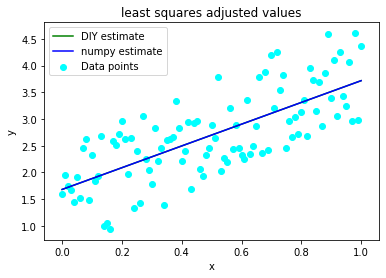

true - m:2.5 b:1.5
DIY - m:0.41898723950296834 b:1.4467257525284476
np - m:2.0334527058937786 b:1.6829211814699023


In [31]:
#used chatgpt to help check the formulas for least squares 

def least_squares(x,y):
    n = len(x)
    m = (n*np.sum(x*y) - np.sum(x)*np.sum(y)) / (n*np.sum(x**2) - np.sum(x)**2)
    b = (np.sum(y) - m*np.sum(x)) / n
    return m, b

np.random.seed(0)

#with randomized vectors 

X = np.random.uniform(0, 5, 10)
X.sort()
Y = np.random.uniform(0, 5, 10)
m, b = least_squares(X, Y)

print(f"Slope: {m}, Intercept: {b}")

plt.plot(np.linspace(0, 5, 5), np.linspace(0, 5, 5)*m + b)
plt.scatter(X, Y)
plt.show()

#making my own data: (y(x) = 2.5x + 1.5)
# with random perturbation

M, B = 2.5, 1.5

X_b = np.arange(0, 1, 0.01)
Y_b = X_b*M + (np.random.uniform(0, 1, 100)+3)

m2, b2 = least_squares(X_b, Y_b)

X_actual, Y_actual = np.linspace(0, 1, 100), np.linspace(0, 1, 100)*m2 + b2

plt.scatter(X_b, Y_b)
plt.plot(X_actual, Y_actual)
plt.show()

residuals = np.abs(Y_actual - Y_b)
print(f"{residuals=}\n")
print(f"{max(residuals)=}, {min(residuals)=}")

#compare against numpy 
A = np.vstack([x, np.ones(len(x))]).T
m2, b2 = np.linalg.lstsq(A, y, rcond=None)[0]
y_est_np = m2*x + b2

#plot
plt.scatter(x, y, color='cyan', label='Data points') # Original data points
plt.plot(x, y_est_diy, color='green', label=f'DIY estimate')
plt.plot(x, y_est_np, color='blue', label=f'numpy estimate')

plt.title('least squares adjusted values')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

print(f"true - m:{m_true} b:{b_true}")
print(f'DIY - m:{m} b:{b}')
print(f'np - m:{m2} b:{b2}')

In [12]:
print("DIY error analyisis: ")

#calculate residuals
res_DIY = y - y_est_diy
small_DIY = np.argmin(np.abs(res_DIY))
big_DIY = np.argmax(np.abs(res_DIY))

#print out importants values
print("first couple residuals:")
print(res_DIY[:10])
print("smallest res")
print("x =", x[small_DIY], "y =", y[small_DIY], "res =", res_DIY[small_DIY])
print("big res")
print("x =", x[big_DIY], "y =", y[big_DIY], "res =", res_DIY[big_DIY])


print()
print()

#calculate residuals
print("numpy error analyisis: ")
res_np = y - y_est_np
small_np = np.argmin(np.abs(res_np))
big_np = np.argmax(np.abs(res_np))

#print out important values
print("first couple residuals:")
print(res_np[:10])
print("smallest res")
print("x =", x[small_np], "y =", y[small_np], "res =", res_np[small_np])
print("big res")
print("x =", x[big_np], "y =", y[big_np], "res =", res_np[big_np])


DIY error analyisis: 
first couple residuals:
[-0.08529417  0.25212302  0.03193652 -0.0791584  -0.31694969  0.13219441
 -0.27975392  0.63328313  0.78172812 -0.37404889]
smallest res
x = 0.28 y = 2.2436966435001438 res = -0.008591295620016925
big res
x = 0.72 y = 4.253522176380674 res = 1.1065150466672513


numpy error analyisis: 
first couple residuals:
[-0.08529417  0.25212302  0.03193652 -0.0791584  -0.31694969  0.13219441
 -0.27975392  0.63328313  0.78172812 -0.37404889]
smallest res
x = 0.28 y = 2.2436966435001438 res = -0.008591295620016481
big res
x = 0.72 y = 4.253522176380674 res = 1.1065150466672513


DIY error analyisis: 
first couple residuals:
[-0.08529417  0.25212302  0.03193652 -0.0791584  -0.31694969  0.13219441
 -0.27975392  0.63328313  0.78172812 -0.37404889]
smallest res
x = 0.28 y = 2.2436966435001438 res = -0.008591295620016925
big res
x = 0.72 y = 4.253522176380674 res = 1.1065150466672513


numpy error analyisis: 
first couple residuals:
[-0.08529417  0.25212302  0.03193652 -0.0791584  -0.31694969  0.13219441
 -0.27975392  0.63328313  0.78172812 -0.37404889]
smallest res
x = 0.28 y = 2.2436966435001438 res = -0.008591295620016481
big res
x = 0.72 y = 4.253522176380674 res = 1.1065150466672513


DIY error analyisis: 
first couple residuals:
[-0.08529417  0.25212302  0.03193652 -0.0791584  -0.31694969  0.13219441
 -0.27975392  0.63328313  0.78172812 -0.37404889]
smallest res
x = 0.28 y = 2.2436966435001438 res = -0.008591295620016925
big res
x = 0.72 y = 4.253522176380674 res = 1.1065150466672513


numpy error analyisis: 
first couple residuals:
[-0.08529417  0.25212302  0.03193652 -0.0791584  -0.31694969  0.13219441
 -0.27975392  0.63328313  0.78172812 -0.37404889]
smallest res
x = 0.28 y = 2.2436966435001438 res = -0.008591295620016481
big res
x = 0.72 y = 4.253522176380674 res = 1.1065150466672513


DIY error analyisis: 
first couple residuals:
[-0.08529417  0.25212302  0.03193652 -0.0791584  -0.31694969  0.13219441
 -0.27975392  0.63328313  0.78172812 -0.37404889]
smallest res
x = 0.28 y = 2.2436966435001438 res = -0.008591295620016925
big res
x = 0.72 y = 4.253522176380674 res = 1.1065150466672513


numpy error analyisis: 
first couple residuals:
[-0.08529417  0.25212302  0.03193652 -0.0791584  -0.31694969  0.13219441
 -0.27975392  0.63328313  0.78172812 -0.37404889]
smallest res
x = 0.28 y = 2.2436966435001438 res = -0.008591295620016481
big res
x = 0.72 y = 4.253522176380674 res = 1.1065150466672513
